In [147]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
%matplotlib widget
from scipy.signal import welch, detrend, csd, coherence, find_peaks
from scipy.linalg import svd
import os

plt.rcParams['font.sans-serif'] = 'Times New Roman'
plt.rcParams['figure.figsize'] = (5, 4.5)
plt.rcParams['figure.dpi'] = 80
plt.rcParams.update({'font.size': 12}) 

In [148]:
# Obtener solo carpetas
carpetas = [carpeta for carpeta in os.listdir('.') if os.path.isdir(carpeta)]

# Mostrar carpetas
print('Carpetas de data:')
for i, carpeta in enumerate(carpetas):
    print(f'[{i}] --> {carpeta}')

Carpetas de data:
[0] --> DATA_CorreaOverland
[1] --> DATA_PuenteItata
[2] --> DATA_PuenteItata+Tren
[3] --> DATA_PuenteItata+Tren_NEW
[4] --> DATA_PuenteItata_Reposo
[5] --> DATA_PuenteItata_Reposo+Tren+Sismo
[6] --> DATA_PuenteItata_Sismo
[7] --> DATA_PuenteItata_Tren+Sismo
[8] --> Export_Artemis
[9] --> Modelos_TeklaStructures
[10] --> Registros


In [149]:
carpeta_data = carpetas[6]
print(f'Carpeta escogida: {carpeta_data}')

Carpeta escogida: DATA_PuenteItata_Sismo


In [150]:
#data = [archivo for archivo in os.listdir('./DATA_CorreaOverland/') if archivo.endswith(".txt")]
data_all = [archivo for archivo in os.listdir(f'./{carpeta_data}/') if archivo.endswith(".txt")]
for i in range(len(data_all)):
    print('[{}]'.format(i),'-->', data_all[i])

[0] --> Proc_Sismo_20260509_223448.txt


In [151]:
# data = data_all[0]
# name_data = data[:-4]
# print(f'Registro escogido: {data}')
# print(f'Nombre data: {name_data}')
# df = pd.read_table(f'./{carpeta_data}/{data}', decimal=".")

for i in range(len(data_all)):
    df = pd.read_table(f'./{carpeta_data}/{data_all[i]}', decimal=".")
    t_total = (pd.to_datetime(df["Time"].iloc[-1], format="%d-%b-%Y %H:%M:%S")-pd.to_datetime(df["Time"].iloc[0], format="%d-%b-%Y %H:%M:%S")).total_seconds() # Tiempo total
    N = len(df) # Cantidad de muestras 
    fs = N / t_total # Frecuencia de muestreo
    #print(f'Cantidad de datos:\t{N}')
    print(f'{data_all[i]}:\t{N} datos\tfs: {fs:.4f} Hz')

Proc_Sismo_20260509_223448.txt:	23031 datos	fs: 250.3370 Hz


In [152]:
# REVISAR DATOS DE SEÑALES EN EL DOMINIO DEL TIEMPO

# ============================================================
# CONFIGURACIÓN SIMPLE
# ============================================================

cols_no_sensores = ["Time", "Date", "fecha", "t", "tiempo"]

FACTOR_ANOMALIA = 30.0       # peak > 5 veces nivel local
VENTANA_RMS_S = 5.0         # RMS móvil de 1 segundo
MIN_AMPLITUD_ABS = 0.05     # evita marcar ruido pequeño; ajustar según unidades
MAX_CANALES_MALOS = 0       # si hay 1 canal malo, ventana mala


def rms_movil(x, n):
    x2 = pd.Series(x**2)
    return np.sqrt(x2.rolling(window=n, center=True, min_periods=max(3, n//4)).median()).to_numpy()


def evaluar_canal_por_peak_local(x, fs):
    x = np.asarray(x, dtype=float)
    x = np.nan_to_num(x, nan=np.nanmedian(x))
    nwin = max(5, int(VENTANA_RMS_S * fs))

    # nivel típico local robusto
    nivel_local = rms_movil(x, nwin)

    # evitar división por cero
    nivel_global = np.sqrt(np.mean(x**2))
    nivel_local = np.where((nivel_local <= 0) | np.isnan(nivel_local),nivel_global,nivel_local)

    ratio = np.abs(x) / nivel_local
    ratio_max = np.nanmax(ratio)

    idx_max = int(np.nanargmax(ratio))
    amp_max = float(np.abs(x[idx_max]))

    canal_malo = (ratio_max > FACTOR_ANOMALIA) and (amp_max > MIN_AMPLITUD_ABS)

    return {
        "canal_malo": canal_malo,
        "ratio_max": ratio_max,
        "amp_max": amp_max,
        "idx_peak": idx_max,
        "t_peak_s": idx_max / fs,
        "motivo": (
            f"peak local {ratio_max:.1f} veces mayor que nivel local, "
            f"t={idx_max/fs:.2f} s"
            if canal_malo else "OK"
        )
    }


def evaluar_ventana_QC_simple(df, archivo, fs):
    columnas_sensores = [
        col for col in df.columns
        if col not in cols_no_sensores and pd.api.types.is_numeric_dtype(df[col])]

    detalle = []

    for col in columnas_sensores:
        r = evaluar_canal_por_peak_local(df[col].values, fs)
        r["archivo"] = archivo
        r["canal"] = col
        detalle.append(r)

    df_detalle = pd.DataFrame(detalle)
    canales_malos = df_detalle[df_detalle["canal_malo"] == True]

    ventana_buena = len(canales_malos) <= MAX_CANALES_MALOS

    resumen = {
        "archivo": archivo,
        "n_canales": len(columnas_sensores),
        "n_canales_malos": len(canales_malos),
        "ventana_buena_FDD": ventana_buena,
        "canales_malos": ", ".join(canales_malos["canal"].astype(str)),
        "motivos": " | ".join(
            canales_malos["canal"].astype(str)
            + ": "
            + canales_malos["motivo"].astype(str)
        )
    }

    return resumen, df_detalle


resumen_ventanas = []
detalle_canales = []

for archivo in data_all:

    df = pd.read_table(f"./{carpeta_data}/{archivo}", decimal=".")

    t_total = (pd.to_datetime(df["Time"].iloc[-1], format="%d-%b-%Y %H:%M:%S")-pd.to_datetime(df["Time"].iloc[0], format="%d-%b-%Y %H:%M:%S")).total_seconds()
    N = len(df)
    fs = N / t_total

    resumen, detalle = evaluar_ventana_QC_simple(df, archivo, fs)
    resumen["N_datos"] = N
    resumen["fs"] = fs
    resumen["duracion_s"] = t_total

    resumen_ventanas.append(resumen)
    detalle_canales.append(detalle)

df_resumen_QC = pd.DataFrame(resumen_ventanas)
df_detalle_QC = pd.concat(detalle_canales, ignore_index=True)


print(f'Cantidad ventanas: {len(data_all)}')
# Índices de ventanas buenas
idx_buenos = df_resumen_QC[df_resumen_QC["ventana_buena_FDD"] == True].index.tolist()
print(f'Cantidad ventanas buenas: {len(idx_buenos)}')

# Índices de ventanas malas
idx_malos = df_resumen_QC[df_resumen_QC["ventana_buena_FDD"] == False].index.tolist()
print(f'Cantidad ventanas malas: {len(idx_malos)}')

display(df_resumen_QC)

Cantidad ventanas: 1
Cantidad ventanas buenas: 1
Cantidad ventanas malas: 0


,archivo,n_canales,n_canales_malos,ventana_buena_FDD,canales_malos,motivos,N_datos,fs,duracion_s
0,Proc_Sismo_20260509_223448.txt,15,0,True,,,23031,250.336957,92.0


In [153]:
def plot_all_accel_rms(df, fs, ventana_rms, name_data, COND):
    
    # Detectar sensores automáticamente desde columnas tipo Ac00_L
    cols_accel = [c for c in df.columns if c != "Time"]
    sensores = sorted(list(set(c.split("_")[0] for c in cols_accel)))
    direcciones = ["L", "T", "V"]

    n = len(df)
    t = np.arange(n) / fs

    n_rms = int(ventana_rms * fs)
    kernel = np.ones(n_rms) / n_rms

    fig, axes = plt.subplots(nrows=len(sensores),ncols=len(direcciones),figsize=(15, 2.4 * len(sensores)),sharex=True)

    if len(sensores) == 1:
        axes = np.array([axes])

    for i, sensor in enumerate(sensores):
        for j, direccion in enumerate(direcciones):

            ax = axes[i, j]
            col = f"{sensor}_{direccion}"

            if col not in df.columns:
                ax.set_visible(False)
                continue

            accel = df[col].to_numpy(dtype=float)

            rms = np.sqrt(np.convolve(accel**2, kernel, mode="valid"))
            t_rms = t[n_rms//2 : n_rms//2 + len(rms)]

            ax.plot(t, accel, color='tab:blue' ,linewidth=0.5, alpha=1, label="Aceleración")
            ax.plot(t_rms, rms, color='red' , linewidth=1.5, label=f"RMS {ventana_rms}s")

            ax.set_title(col, fontsize=10, fontweight="bold")
            ax.grid(True, alpha=0.25)
            ax.minorticks_on()
            ax.grid(which="minor", alpha=0.08)
            
            #ax.set_ylim(-1.5, 1.5)

            if j == 0:
                ax.set_ylabel("Acel. [g]")

            if i == len(sensores) - 1:
                ax.set_xlabel("Tiempo [s]")

            ax.legend(fontsize=7, loc="upper right", frameon=False)

    fig.suptitle(f"{name_data}\nAceleración + RMS móvil",fontsize=15,fontweight="bold")

    plt.tight_layout()
    if COND == True:
        plt.savefig(f"DATA_PuenteItata/Figures_ACCEL_ALL/PUENTE_ITATA_ACCEL_{name_data}.jpg", dpi=800)
    plt.show()

In [154]:
# for i in [23]: #idx_buenos range(len(data_all))
#     data = data_all[i]
#     name_data = data[:-4]
#     print(f'Registro escogido: {data}')
#     print(f'Nombre data: {name_data}')
#     df = pd.read_table(f'./{carpeta_data}/{data}', decimal=".")
#     display(df)
#     plot_all_accel_rms(df,fs=fs,ventana_rms=5,name_data=name_data, COND=False)

In [155]:
# for i in idx_buenos: #range(len(data_all))
#     data = data_all[i]
#     name_data = data[:-4]
#     print(f'Registro escogido: {data}')
#     print(f'Nombre data: {name_data}')
#     df = pd.read_table(f'./{carpeta_data}/{data}', decimal=".")
#     plot_all_accel_rms(df,fs=fs,ventana_rms=5,name_data=name_data, COND=False)

In [156]:
# REMUESTREARM CANALES A FS COMÚN

from scipy.signal import resample_poly
from fractions import Fraction

# ============================================================
# CONFIGURACIÓN
# ============================================================

fs_target = 250.0
cols_no_sensores = ["Time", "Date", "fecha", "t", "tiempo"]

# ============================================================
# FUNCIÓN DE REMUESTREO
# ============================================================

def remuestrear_df_a_fs(df, fs_original, fs_target=250.0):
    """
    Remuestrea todos los canales numéricos del DataFrame a fs_target.
    Mantiene solo columnas de sensores y genera un nuevo vector tiempo.
    """

    columnas_sensores = [
        col for col in df.columns
        if col not in cols_no_sensores and pd.api.types.is_numeric_dtype(df[col])]

    # razón racional fs_target / fs_original
    ratio = Fraction(fs_target / fs_original).limit_denominator(1000)
    up = ratio.numerator
    down = ratio.denominator

    data_resampled = {}

    for col in columnas_sensores:
        x = df[col].to_numpy(dtype=float)
        x = np.nan_to_num(x, nan=np.nanmedian(x))
        
        data_resampled[col] = resample_poly(x, up, down)

    # ajustar todos los canales al mismo largo
    n_min = min(len(v) for v in data_resampled.values())

    for col in data_resampled:
        data_resampled[col] = data_resampled[col][:n_min]

    df_res = pd.DataFrame(data_resampled)

    # nuevo vector tiempo
    df_res.insert(0, "t_s", np.arange(n_min) / fs_target)

    return df_res


# ============================================================
# FILTRAR VENTANAS BUENAS
# ============================================================

df_buenas = df_resumen_QC[df_resumen_QC["ventana_buena_FDD"] == True].copy()

idx_buenos = df_buenas.index.tolist()
archivos_buenos = df_buenas["archivo"].tolist()

# print("Índices buenos:", idx_buenos)
# print("Cantidad ventanas buenas:", len(idx_buenos))


# ============================================================
# REMUESTREAR TODAS LAS VENTANAS BUENAS A 250 Hz
# ============================================================

data_resampled_250 = []
info_resampled = []

for idx, row in df_buenas.iterrows():

    archivo = row["archivo"]
    fs_original = float(row["fs"])

    df = pd.read_table(f"./{carpeta_data}/{archivo}", decimal=".")

    df_250 = remuestrear_df_a_fs(df, fs_original, fs_target=fs_target)

    data_resampled_250.append(df_250)

    info_resampled.append({
        "idx_original": idx,
        "archivo": archivo,
        "fs_original": fs_original,
        "fs_target": fs_target,
        "N_original": len(df),
        "N_resampled": len(df_250),
        "duracion_original_s": row["duracion_s"],
        "duracion_resampled_s": len(df_250) / fs_target
    })

df_info_resampled = pd.DataFrame(info_resampled)

df_info_resampled

,idx_original,archivo,fs_original,fs_target,N_original,N_resampled,duracion_original_s,duracion_resampled_s
0,0,Proc_Sismo_20260509_223448.txt,250.336957,250.0,23031,23001,92.0,92.004


In [157]:
# NORMALIZAR CANALES POR RMS ANTES DE LA FDD
def normalizar_canales_rms(df, canales):
    """
    Normaliza cada canal:
    - elimina media
    - divide por RMS

    Resultado:
    RMS = 1 en todos los canales
    """

    df_norm = df.copy()
    for canal in canales:
        x = df_norm[canal].to_numpy(dtype=float)
        # eliminar NaN
        x = np.nan_to_num(x, nan=np.nanmedian(x))
        # eliminar media
        x = x - np.mean(x)
        # RMS
        rms = np.sqrt(np.mean(x**2))
        # normalización
        if rms > 0:
            x = x / rms
        df_norm[canal] = x
    return df_norm

In [158]:
# NORMALIZAR CANALES POR DIRECCIÓN POR RMS ANTES DE LA FDD
def normalizar_canales_por_direccion(
    df,
    direcciones=("L", "T", "V"),
    metodo="rms",
    remove_mean=True,
    eps=1e-12,
    col_tiempo="Time",
    return_factores=False
):
    """
    Normaliza canales agrupados por dirección.

    Ejemplo columnas:
    Ac00_L, Ac00_T, Ac00_V, Ac01_L, ...

    Para cada dirección:
    - toma todos los canales terminados en _L, _T o _V
    - elimina media por canal
    - calcula un factor global de normalización por dirección
    - divide todos los canales de esa dirección por el mismo factor

    Resultado:
    - mantiene relaciones relativas entre sensores de la misma dirección
    - evita que una dirección domine por amplitud global
    """

    df_norm = df.copy()
    factores = {}

    for direccion in direcciones:

        canales_dir = [
            col for col in df_norm.columns
            if col != col_tiempo and col.endswith(f"_{direccion}")
        ]

        if len(canales_dir) == 0:
            print(f"No se encontraron canales para dirección {direccion}")
            continue

        # matriz: filas = tiempo, columnas = sensores de esa dirección
        X = df_norm[canales_dir].to_numpy(dtype=float)

        # reemplazar NaN por mediana de cada canal
        for j in range(X.shape[1]):
            xj = X[:, j]
            mediana = np.nanmedian(xj)
            X[:, j] = np.nan_to_num(xj, nan=mediana)

        # eliminar media por canal
        if remove_mean:
            X = X - np.nanmean(X, axis=0)

        # factor global por dirección
        if metodo == "rms":
            factor = np.sqrt(np.nanmean(X**2))

        elif metodo == "std":
            factor = np.nanstd(X)

        elif metodo == "max":
            factor = np.nanmax(np.abs(X))

        elif metodo == "p95":
            factor = np.nanpercentile(np.abs(X), 95)

        else:
            factor = 1.0

        if factor > eps:
            X_norm = X / factor
        else:
            X_norm = X.copy()
            print(f"Factor muy bajo en dirección {direccion}: {factor}")

        df_norm[canales_dir] = X_norm
        factores[direccion] = factor

    if return_factores:
        return df_norm, factores

    return df_norm

In [159]:
# fs = 250.0
# direccion = "ALL"

# if direccion == "ALL": canales = [col for col in df.columns if col != "Time"]
# else: canales = [f"Ac00_{direccion}",f"Ac01_{direccion}",f"Ac02_{direccion}",f"Ac03_{direccion}",f"Ac05_{direccion}",]

# data = data_all[1]
# name_data = data[:-4]
# df = pd.read_table(f'./{carpeta_data}/{data}', decimal=".")
# df_norm = normalizar_canales_rms(df, canales)
# df_norm

# plot_all_accel_rms(df,fs=fs,ventana_rms=5,name_data=name_data, COND=False)
# plot_all_accel_rms(df_norm,fs=fs,ventana_rms=5,name_data=name_data, COND=False)

In [160]:
def FDD(df,canales,fs,nperseg,name_data,COND):
    # ============================================================
    # 1) DEFINICIÓN DE PARÁMETROS GENERALES
    # ============================================================

    # ============================================================
    # 2) CONFIGURACIÓN DE WELCH / CSD
    # ============================================================

    # Para registros largos, usar ventanas largas mejora la resolución frecuencial
    # df_frec = fs / nperseg

    noverlap = nperseg // 2
    # print("\nParámetros espectrales:")
    # print("nperseg:", nperseg)
    # print("noverlap:", noverlap)
    # print("Resolución frecuencial aproximada [Hz]:", fs/nperseg)

    # ============================================================
    # 3) PSD PARA TODOS LOS CANALES
    # ============================================================

    psd = {}
    for col in canales:

        f, Pxx = welch(
            df[col].values,
            fs=fs,
            window="hann",
            nperseg=nperseg,
            noverlap=noverlap,
            detrend="constant",
            scaling="density"
        )

        psd[col] = Pxx


    # ============================================================
    # 4) GRÁFICO PSD - TODOS LOS CANALES
    # ============================================================

    # plt.figure(figsize=(10, 4.5), dpi=100)

    # for col in canales:
    #     plt.semilogy(f, psd[col], alpha=1, linewidth=1, label=col)

    # plt.xlim(0, 30)
    # plt.xlabel("Frecuencia [Hz]", fontsize=12)
    # plt.ylabel("PSD [g²/Hz]", fontsize=12)
    # plt.title(f'{name_data}\nDensidad espectral de potencia - todos los canales', fontsize=14, fontweight='bold')
    # plt.grid(which="major", alpha=0.15)
    # plt.minorticks_on()
    # plt.grid(which="minor", alpha=0.05)
    # plt.legend(loc=1, fontsize=9, ncol=1, frameon=True)
    # plt.tight_layout()
    # plt.show()


    # ============================================================
    # 5) FDD - MATRIZ ESPECTRAL MULTICANAL
    # ============================================================

    n_canales = len(canales)
    n_freq = len(f)

    # Matriz espectral:
    # Gyy[k, i, j] corresponde a la CSD entre canal i y canal j
    # para la frecuencia f[k]
    Gyy = np.zeros((n_freq, n_canales, n_canales), dtype=complex)

    for i, col_i in enumerate(canales):
        for j, col_j in enumerate(canales):

            f_csd, Pij = csd(
                df[col_i].values,
                df[col_j].values,
                fs=fs,
                window="hann",
                nperseg=nperseg,
                noverlap=noverlap,
                detrend="constant",
                scaling="density"
            )

            Gyy[:, i, j] = Pij


    # ============================================================
    # 6) SVD DE LA MATRIZ ESPECTRAL
    # ============================================================

    # Valores singulares para cada frecuencia
    S_valores = np.zeros((n_freq, n_canales))

    # Vectores singulares izquierdos
    # Estos pueden usarse después como estimación de formas modales
    U_vectores = np.zeros((n_freq, n_canales, n_canales), dtype=complex)

    for k in range(n_freq):

        U, S, VH = svd(Gyy[k, :, :])

        S_valores[k, :] = S
        U_vectores[k, :, :] = U


    # ============================================================
    # 7) GRÁFICO FDD - VALORES SINGULARES
    # ============================================================

    # plt.figure(figsize=(10, 4.5), dpi=100)

    # # Cantidad de valores singulares a graficar
    # # Para no saturar el gráfico, normalmente basta con 4 a 6
    # n_sv_plot = min(4, n_canales)

    # for i in range(n_sv_plot):
    #     plt.semilogy(f, S_valores[:, i], linewidth=1, label=f"SV{i+1}")

    # plt.xlim(0, 30)
    # plt.xlabel("Frecuencia [Hz]", fontsize=12)
    # plt.ylabel("Valores singulares", fontsize=12)
    # plt.title(f'{name_data}\nFDD - valores singulares de la matriz espectral', fontsize=14, fontweight='bold')
    # plt.grid(which="major", alpha=0.15)
    # plt.minorticks_on()
    # plt.grid(which="minor", alpha=0.05)
    # plt.legend(loc=1, fontsize=9, ncol=1, frameon=True)
    # plt.tight_layout()
    # plt.show()


    # ============================================================
    # 8) OPCIONAL - IDENTIFICAR FRECUENCIAS CANDIDATAS DESDE SV1
    # ============================================================

    from scipy.signal import find_peaks

    SV1 = S_valores[:, 0]

    # Se buscan peaks en SV1.
    # prominence controla qué tan dominante debe ser un peak.
    peaks, props = find_peaks(SV1,prominence=np.max(SV1) * 0.00001,distance=1)

    freq_peaks = f[peaks]
    sv1_peaks = SV1[peaks]

    # Filtrar solo hasta 30 Hz
    mask = freq_peaks <= 30

    freq_peaks = freq_peaks[mask]
    sv1_peaks = sv1_peaks[mask]

    # print("\nFrecuencias candidatas FDD desde SV1:")
    # for fp, amp in zip(freq_peaks, sv1_peaks):
    #     print(f"{fp:.3f} Hz   |   SV1 = {amp:.4e}")


    # ============================================================
    # 9) GRÁFICO FDD CON PEAKS IDENTIFICADOS
    # ============================================================

    # plt.figure(figsize=(10, 4.5), dpi=100)

    # plt.semilogy(f, SV1, color='tab:blue' ,linewidth=1, label="SV1")
    # #plt.semilogy(freq_peaks, sv1_peaks, "o", label="Peaks candidatos")

    # plt.semilogy(freq_peaks, sv1_peaks,"o",markerfacecolor="none",markeredgecolor="red",markeredgewidth=1.5,label="Peaks candidatos")

    # for fp, amp in zip(freq_peaks, sv1_peaks):
    #     plt.text(fp, amp, f" {fp:.2f} Hz", fontsize=8, rotation=15)
    #     #plt.axvline(fp, color='gray', linestyle='--', linewidth=0.5, alpha=1)

    # plt.xlim(0, 30)
    # plt.margins(y=0.1)
    # plt.xlabel("Frecuencia [Hz]", fontsize=12)
    # plt.ylabel("Valor singular SV1", fontsize=12)
    # plt.title(f'{name_data}\nFDD - identificación preliminar de frecuencias candidatas', fontsize=14, fontweight='bold')
    # plt.grid(which="major", alpha=0.15)
    # plt.minorticks_on()
    # plt.grid(which="minor", alpha=0.05)
    # plt.legend(loc=4, fontsize=9, ncol=1, frameon=True)
    # plt.tight_layout()
    # if COND == True:
    #     plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_FDD_{name_data}.jpg", dpi=800)
    # plt.show()
    
    return f, SV1, Gyy, S_valores, U_vectores, freq_peaks, sv1_peaks

In [161]:
# f_all = []
# SV1_all = []
# U_vectores = []

# #fs = 250 #frecuencia de muestreo [Hz]
# nperseg = 2048*2 #4086 - 40960 #resolución frecuencial
# direccion = 'ALL'

# for i in idx_buenos: #idx_buenos range(len(data_all))
#     df = pd.read_table(f'./{carpeta_data}/{data_all[i]}', decimal=".")
#     t_total = (pd.to_datetime(df["Time"].iloc[-1], format="%d-%b-%Y %H:%M:%S")-pd.to_datetime(df["Time"].iloc[0], format="%d-%b-%Y %H:%M:%S")).total_seconds() # Tiempo total
#     N = len(df) # Cantidad de muestras 
#     fs = N / t_total # Frecuencia de muestreo
#     if direccion == 'ALL': canales = list(df.columns[1:])
#     else: canales = [f'Ac00_{direccion}', f'Ac01_{direccion}', f'Ac02_{direccion}', f'Ac03_{direccion}', f'Ac05_{direccion}']
#     case = FDD(df, canales, fs, nperseg, data_all[i][:-4], False)
#     f_all.append(case[0])
#     SV1_all.append(case[1])
#     U_vectores.append(case[4])
    

In [162]:
def corregir_signos(df):
    df = df.copy()
    canales_invertidos = ["Ac03_T",]
    for col in canales_invertidos:
        if col in df.columns:
            df[col] = -df[col]

    return df

In [163]:
data_resampled_250_CoSig = []

for ci in range(0, len(data_resampled_250)):
    df_corregido = corregir_signos(data_resampled_250[ci])
    data_resampled_250_CoSig.append(df_corregido)

In [164]:
2048*2

4096

In [182]:
# ============================================================
# FDD CON DATOS YA REMUESTREADOS A 250 Hz
# ============================================================

f_all = []
SV1_all = []
U_vectores_all = []

fs = 250.0
nperseg = 2048*2
direccion = "ALL" #L:Longitudinal T:transversal V:vertical ALL:todas

for k, df in enumerate(data_resampled_250_CoSig):
    archivo = df_info_resampled.loc[k, "archivo"]
    idx_original = df_info_resampled.loc[k, "idx_original"]
    #print(f"Procesando k={k} | idx_original={idx_original} | {archivo}")
    if direccion == "ALL": canales = [col for col in df.columns if col != "t_s"]
    else: canales = [f"Ac00_{direccion}",f"Ac01_{direccion}",f"Ac02_{direccion}",f"Ac03_{direccion}",f"Ac05_{direccion}",]
    # NORMALIZAR
    df_norm = normalizar_canales_rms(df, canales)
    df_norm_canal = normalizar_canales_por_direccion(df,direcciones=("L", "T", "V"),metodo="rms",col_tiempo="Time")
    # FDD
    case = FDD(df_norm_canal, canales, fs, nperseg, archivo[:-4], False)
    f_all.append(case[0])
    SV1_all.append(case[1])
    U_vectores_all.append(case[4])

In [183]:
if direccion == 'L': name_direc = 'Longitudinal'
elif direccion == 'T': name_direc = 'Transversal'
elif direccion == 'V': name_direc = 'Vertical'
elif direccion == 'ALL': name_direc = 'Multidireccional' #Multidireccional

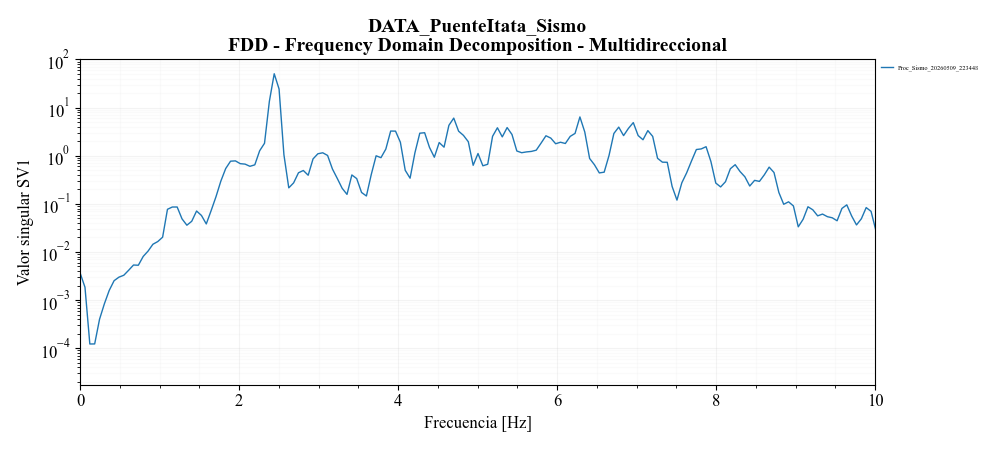

In [184]:
plt.figure(figsize=(10, 4.5), dpi=100)
# plt.axvline(2.44, color='k', linestyle='--', linewidth=1)
# plt.axvline(4.70, color='k', linestyle='--', linewidth=1)
# plt.axvline(6.16, color='k', linestyle='--', linewidth=1)
for i in range(0, len(f_all)):
    plt.semilogy(f_all[i], SV1_all[i], linewidth=1, label=f"{archivos_buenos[i][:-4]}")
plt.xlim(0, 10)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1", fontsize=12)
plt.title(f'{carpeta_data}\nFDD - Frequency Domain Decomposition - {name_direc}', fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=2, fontsize=4.5, ncol=1, frameon=False, bbox_to_anchor=(1,1))
plt.tight_layout()

#plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_FDD_ALL_ACOT.jpg", dpi=800)
plt.show()

In [168]:
a

NameError: name 'a' is not defined

el percentil actúa como un filtro estadístico de persistencia.

In [ ]:
f_all_np = np.array(f_all)
SV1_all_np = np.array(SV1_all)

# SV1_all_mean = np.mean(SV1_all_np, axis=0)
# SV1_all_min = np.min(SV1_all_np, axis=0)
# SV1_all_max = np.max(SV1_all_np, axis=0)

perc = 95
SV_per = np.percentile(SV1_all_np, perc, axis=0)
f_per = np.percentile(f_all_np, 100, axis=0)

peaks, props = find_peaks(SV_per,prominence=np.max(SV_per)*0.0000001,distance=1)
freq_peaks = f_per[peaks]; sv1_peaks = SV_per[peaks]
# Filtrar solo hasta 30 Hz
mask = freq_peaks <= 30
freq_peaks = freq_peaks[mask]
sv1_peaks = sv1_peaks[mask]

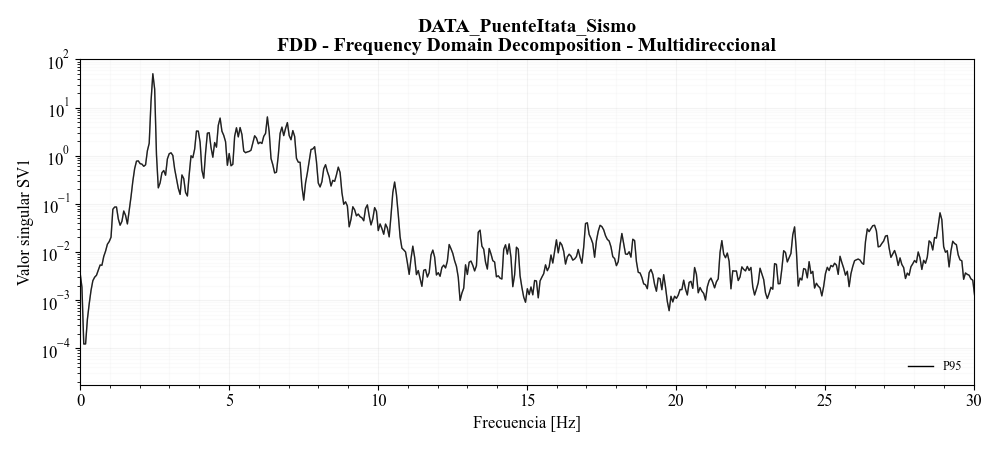

In [ ]:
plt.figure(figsize=(10, 4.5), dpi=100)
plt.semilogy(f_per, SV_per, color='k', alpha=1, linewidth=1, label=f"P{perc}")
    #plt.axvline(fp, color='gray', linestyle='--', linewidth=0.5, alpha=1)
#plt.semilogy(f_mean, SV1_all_mean, color='blue', alpha=1, linewidth=1, label="PROM")
#plt.semilogy(f_min, SV1_all_min, color='lime', alpha=1, linewidth=1, label="MAX")
for i in range(0, len(f_all)):
    plt.semilogy(f_all[i], SV1_all[i], color='gray', alpha=0.25, linewidth=1)
plt.xlim(0, 30)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1", fontsize=12)
plt.title(f'{carpeta_data}\nFDD - Frequency Domain Decomposition - {name_direc}', fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=4, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()

#plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_FDD_ALL_P95.jpg", dpi=800)
plt.show()

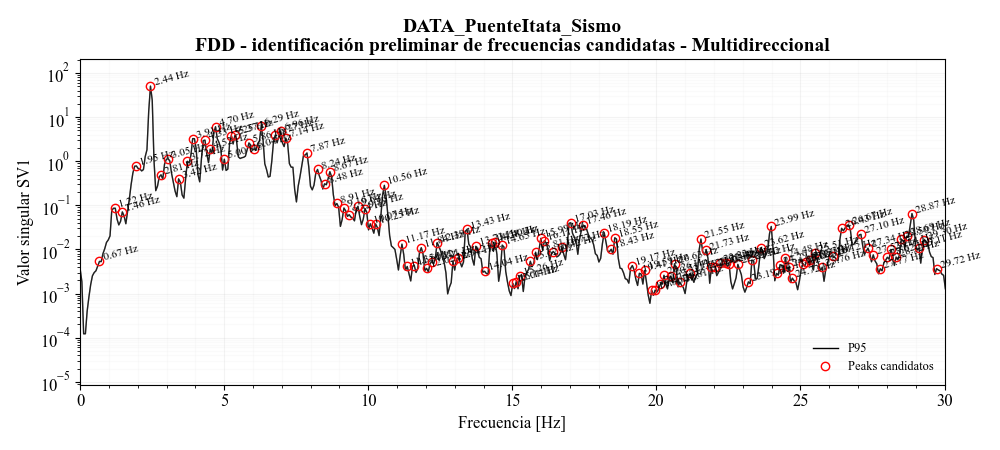

In [ ]:
plt.figure(figsize=(10, 4.5), dpi=100)
plt.semilogy(f_per, SV_per, color='k', alpha=1, linewidth=1, label=f"P{perc}")
plt.semilogy(freq_peaks, sv1_peaks,"o",markerfacecolor="none",markeredgecolor="red",markeredgewidth=1,label="Peaks candidatos")
for fp, amp in zip(freq_peaks, sv1_peaks):
    plt.text(fp, amp, f" {fp:.2f} Hz", fontsize=8, rotation=15)
    #plt.axvline(fp, color='gray', linestyle='--', linewidth=0.5, alpha=1)
#plt.semilogy(f_mean, SV1_all_mean, color='blue', alpha=1, linewidth=1, label="PROM")
#plt.semilogy(f_min, SV1_all_min, color='lime', alpha=1, linewidth=1, label="MAX")
for i in range(0, len(f_all)):
    plt.semilogy(f_all[i], SV1_all[i], color='gray', alpha=0.25, linewidth=1)
plt.xlim(0, 30)
plt.margins(y=0.1)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1", fontsize=12)
plt.title(f'{carpeta_data}\nFDD - identificación preliminar de frecuencias candidatas - {name_direc}', fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=4, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()

#plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_FDD_ALL_P95_ACOT.jpg", dpi=800)
plt.show()

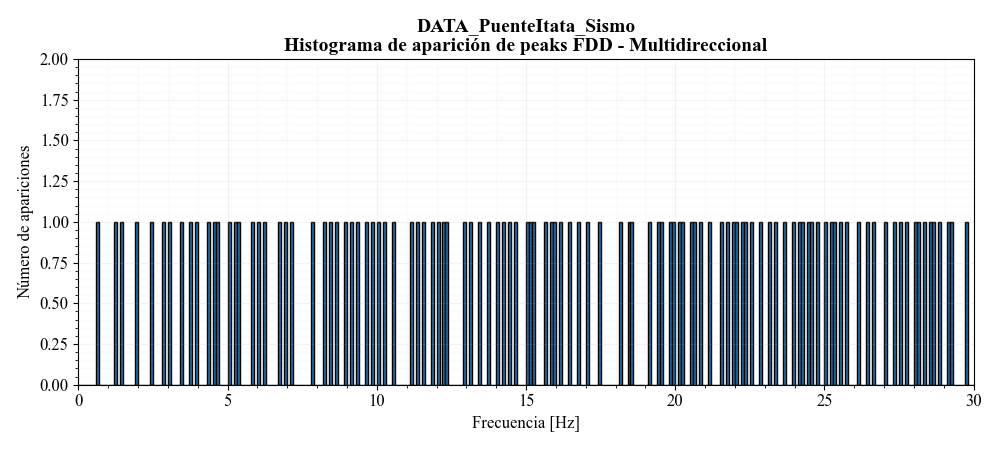

In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.signal import find_peaks

# ==========================================================
# HISTOGRAMA DE APARICIONES DE PEAKS FDD
# ==========================================================

freqs_detectadas = []

for i in range(len(SV1_all_np)):
    f_i = f_all_np[i]
    sv_i = SV1_all_np[i]
    # Limitar rango de interés
    mask = (f_i >= 0.2) & (f_i <= 30)
    f_i = f_i[mask]
    sv_i = sv_i[mask]
    # Detectar peaks por ventana
    peaks, props = find_peaks(sv_i,prominence=np.max(sv_i)*0.0000001,distance=1)
    # Guardar frecuencias detectadas
    freqs_detectadas.extend(f_i[peaks])

freqs_detectadas = np.array(freqs_detectadas)

# ==========================================================
# GRAFICAR HISTOGRAMA
# ==========================================================

plt.figure(figsize=(10, 4.5), dpi=100)
bins = np.arange(0, 30.1, 0.1)
plt.hist(freqs_detectadas, bins=bins, edgecolor='black')
plt.xlim(0, 30)
plt.ylim(0,len(SV1_all_np)+1)
plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Número de apariciones', fontsize=12)
plt.title(f'{carpeta_data}\nHistograma de aparición de peaks FDD - {name_direc}', fontsize=14, fontweight='bold')
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
#plt.legend(loc=4, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
#plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_HISTOGRAMA.jpg", dpi=800)
plt.show()

#Persistencia temporal

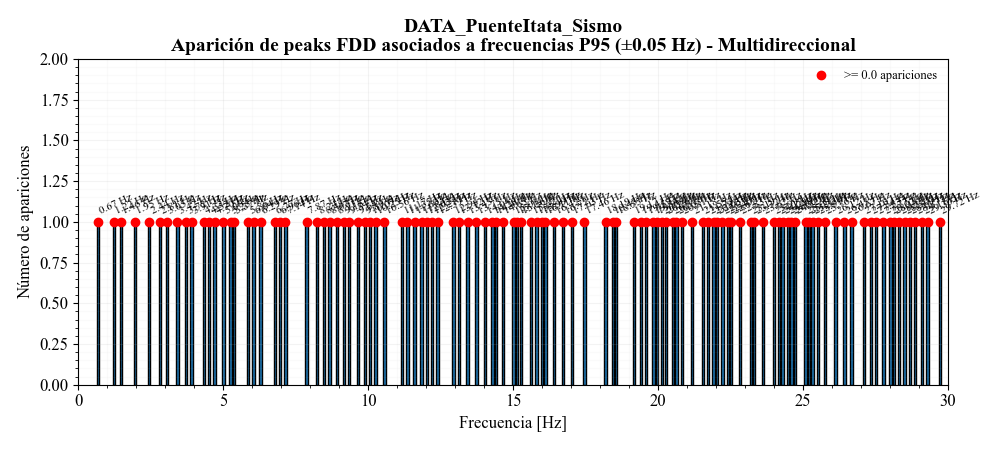

In [ ]:
# ============================================================
# CONTAR APARICIONES EN TORNO A LAS FRECUENCIAS P95
# ============================================================

tolerancia = 0.05   # Hz #f_all_np[0][1] - f_all_np[0][0]
umbral = np.round(len(SV1_all_np)*0.25)

apariciones_per = []
for f0 in freq_peaks:
    n = np.sum(np.abs(freqs_detectadas - f0) <= tolerancia)
    apariciones_per.append(n)
apariciones_per = np.array(apariciones_per)

# Frecuencias P95 con más de umbral apariciones
mask_peaks = apariciones_per >= umbral

f_peaks = freq_peaks[mask_peaks]
conteo_peaks = apariciones_per[mask_peaks]
# ============================================================
# GRAFICAR COMO HISTOGRAMA/BARRAS, PERO CON FRECUENCIAS P95
# ============================================================

plt.figure(figsize=(10, 4.5), dpi=100)
# Barras en las frecuencias exactas del P95
plt.bar(freq_peaks,apariciones_per,width=0.08,edgecolor='black')
# Peaks importantes
plt.plot(f_peaks,conteo_peaks,'ro',markersize=6,label=f'>= {umbral} apariciones')

# Texto sobre peaks importantes
for f, c in zip(f_peaks, conteo_peaks):
    plt.text(f,c + c*0.05,f'{f:.2f} Hz',fontsize=8,rotation=25,ha='left')

plt.xlim(0, 30)
plt.ylim(0,len(SV1_all_np)+1)

plt.xlabel('Frecuencia [Hz]', fontsize=12)
plt.ylabel('Número de apariciones', fontsize=12)
plt.title(f'{carpeta_data}\nAparición de peaks FDD asociados a frecuencias P{perc} (±{tolerancia} Hz) - {name_direc}',fontsize=14,fontweight='bold')

plt.grid(which='major', alpha=0.15)
plt.minorticks_on()
plt.grid(which='minor', alpha=0.05)

plt.legend(loc=1,fontsize=9,frameon=False)
plt.tight_layout()
#plt.savefig(f"DATA_PuenteItata/Figures/PUENTE_ITATA_HISTOGRAMA_P95.jpg", dpi=800)
plt.show()

In [ ]:
# ============================================================
# SCORE PONDERADO POR APARICIONES
# ============================================================

# Normalización de apariciones entre 0 y 1
w_ap = apariciones_per / np.max(apariciones_per)

# Factor de amplificación controlado
alpha = 1.0  # puedes probar 0.5, 1.0, 2.0

scores = []
idx_peaks_en_fper = []
sv_peaks = []

for f0, w, n_ap in zip(freq_peaks, w_ap, apariciones_per):

    # encontrar el índice más cercano en f_per
    idx = np.argmin(np.abs(f_per - f0))

    idx_peaks_en_fper.append(idx)

    sv0 = SV_per[idx]
    sv_peaks.append(sv0)

    # score ponderado
    score = sv0 * (1 + alpha * w)

    scores.append(score)

scores = np.array(scores)
sv_peaks = np.array(sv_peaks)
idx_peaks_en_fper = np.array(idx_peaks_en_fper)

SV_per_weighted = SV_per.copy()
# alpha = 10.0
# ancho_Hz = tolerancia  # ancho de influencia alrededor del peak

for f0, w in zip(freq_peaks, w_ap):
    factor = 1 + alpha * w
    mask = np.abs(f_per - f0) <= tolerancia
    # ponderación suave tipo campana
    gauss = np.exp(-0.5 * ((f_per[mask] - f0) / (tolerancia/2))**2)
    SV_per_weighted[mask] = SV_per_weighted[mask] * (1 + alpha * w * gauss)

In [ ]:
# # Copia de la curva original P98
# SV_per_weighted = SV_per.copy()

# # Normalizar apariciones
# w_ap = apariciones_p98 / np.max(apariciones_p98)
# alpha = 2.0   # intensidad del peso, probar 1, 2, 3

# for f0, w in zip(freq_peaks, w_ap):
#     idx = np.argmin(np.abs(f_per - f0))
#     # factor de amplificación en el peak
#     factor = 1 + alpha * w
#     SV_per_weighted[idx] = SV_per_weighted[idx] * factor

C:\Users\mihrs\AppData\Local\Temp\ipykernel_7028\3823406712.py:1: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 4.5), dpi=100)


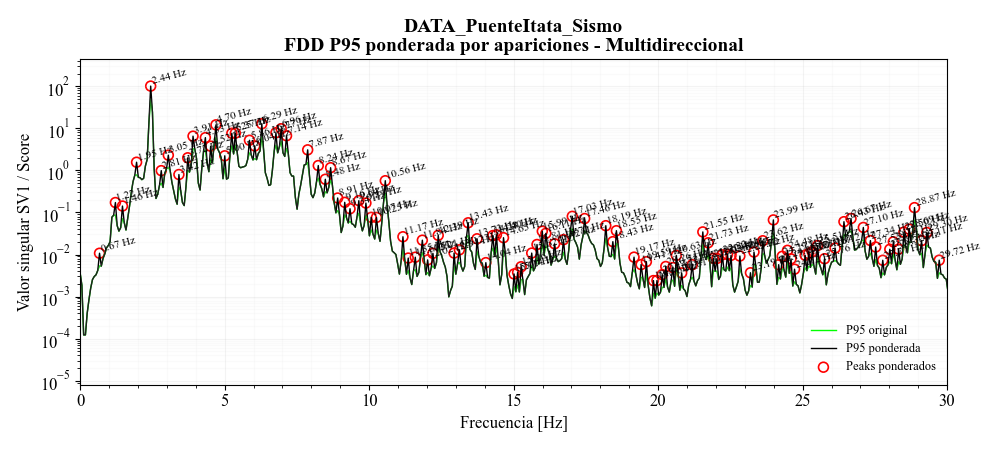

In [ ]:
plt.figure(figsize=(10, 4.5), dpi=100)
plt.semilogy(f_per, SV_per, color="lime", linewidth=1, alpha=1, label=f"P{perc} original")
plt.semilogy(f_per, SV_per_weighted, color="k", linewidth=1, label=f"P{perc} ponderada")

plt.scatter(freq_peaks,SV_per_weighted[[np.argmin(np.abs(f_per - f0)) for f0 in freq_peaks]],s=50*w_ap,facecolor="none",edgecolor="red",linewidth=1.2,label="Peaks ponderados")

for f0, y0, n in zip(
    freq_peaks,SV_per_weighted[[np.argmin(np.abs(f_per - f0)) for f0 in freq_peaks]],apariciones_per):
    plt.text(f0, y0*1.1,f"{f0:.2f} Hz",fontsize=8, rotation=15) #ha="center",va="bottom")

for i in range(0, len(f_all)):
    plt.semilogy(f_all[i], SV1_all[i], color='gray', alpha=0.25, linewidth=1)

plt.xlim(0, 30)
plt.margins(y=0.1)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1 / Score", fontsize=12)
plt.title(f"{carpeta_data}\nFDD P{perc} ponderada por apariciones - {name_direc}", fontsize=14, fontweight="bold")
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=4, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
df_score = pd.DataFrame({
    "f_peak_Hz": freq_peaks,
    # "SV_P98": sv_peaks,
    "apariciones": apariciones_per,
    "peso_apariciones": w_ap,
    "score_modal": scores
})

df_score = (df_score[df_score["f_peak_Hz"] <= 10].sort_values("score_modal", ascending=False).reset_index(drop=True))
df_score

,f_peak_Hz,apariciones,peso_apariciones,score_modal
0,2.441406,1,1.0,101.125041
1,6.286621,1,1.0,12.815439
2,4.699707,1,1.0,12.111296
3,6.958008,1,1.0,9.764974
4,6.774902,1,1.0,7.864349
5,5.371094,1,1.0,7.699202
6,5.249023,1,1.0,7.625291
7,7.141113,1,1.0,6.659308
8,3.906250,1,1.0,6.516604
9,4.333496,1,1.0,6.016212


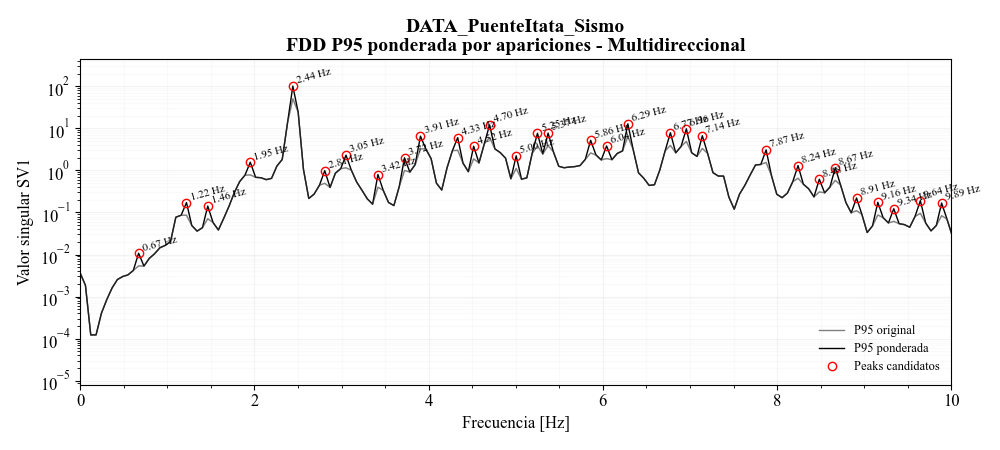

In [ ]:
peaks_pond, props_pond = find_peaks(SV_per_weighted,prominence=np.max(SV_per_weighted)*0.0000001,distance=1)
freq_peaks_pond = f_per[peaks_pond]; sv1_peaks_pond = SV_per_weighted[peaks_pond]
# Filtrar solo hasta 30 Hz
mask = freq_peaks_pond <= 10
freq_peaks_pond = freq_peaks_pond[mask]
sv1_peaks_pond = sv1_peaks_pond[mask]

plt.figure(figsize=(10, 4.5), dpi=100)
plt.semilogy(f_per, SV_per, color="gray", linewidth=1, alpha=1, label=f"P{perc} original")
plt.semilogy(f_per, SV_per_weighted, color="k", linewidth=1, label=f"P{perc} ponderada")

plt.semilogy(freq_peaks_pond, sv1_peaks_pond,"o",markerfacecolor="none",markeredgecolor="red",markeredgewidth=1,label="Peaks candidatos")
for fp, amp in zip(freq_peaks_pond, sv1_peaks_pond):
    plt.text(fp, amp*1.1, f" {fp:.2f} Hz", fontsize=8, rotation=15)

for i in range(0, len(f_all)):
    plt.semilogy(f_all[i], SV1_all[i], color='gray', alpha=0.25, linewidth=1)

plt.xlim(0, 10)
plt.margins(y=0.1)
plt.xlabel("Frecuencia [Hz]", fontsize=12)
plt.ylabel("Valor singular SV1", fontsize=12)
plt.title(f"{carpeta_data}\nFDD P{perc} ponderada por apariciones - {name_direc}", fontsize=14, fontweight="bold")
plt.grid(which="major", alpha=0.15)
plt.minorticks_on()
plt.grid(which="minor", alpha=0.05)
plt.legend(loc=4, fontsize=9, ncol=1, frameon=False)
plt.tight_layout()
plt.show()

Se identificaron frecuencias candidatas mediante FDD por ventanas temporales, curva estadística P95 y análisis de persistencia temporal. Las frecuencias seleccionadas corresponden a peaks energéticos de la curva P95 que además presentan recurrencia en múltiples ventanas de medición dentro de una tolerancia frecuencial definida por la resolución espectral.

In [ ]:
df

,t_s,Ac00_L,Ac00_T,Ac00_V,Ac01_L,Ac01_T,Ac01_V,Ac02_L,Ac02_T,Ac02_V,Ac03_L,Ac03_T,Ac03_V,Ac05_L,Ac05_T,Ac05_V
0,0.000,6.844506e-06,-8.764554e-05,0.000005,1.006673e-04,-3.997504e-04,1.937851e-04,-3.810820e-06,6.714587e-05,9.427783e-05,-1.051044e-04,1.760283e-04,-1.869773e-04,-6.560091e-05,-0.000448,0.000047
1,0.004,-7.341656e-05,-3.917611e-05,-0.000056,2.103976e-04,-4.577988e-04,-1.042058e-04,3.707441e-05,-1.460619e-05,4.242480e-05,3.099209e-05,4.521046e-04,1.796156e-04,4.458538e-05,-0.000031,0.000343
2,0.008,-1.464736e-04,-5.577030e-05,0.000177,-2.077555e-05,-4.748497e-04,1.783369e-04,1.545369e-04,-1.869599e-04,1.392376e-04,-1.026218e-04,1.708518e-04,1.929925e-04,1.993214e-04,0.000054,0.000051
3,0.012,1.438730e-05,-6.934702e-05,0.000097,-4.416816e-05,-3.023385e-04,2.098882e-04,7.299899e-05,-9.600221e-05,2.474568e-04,-1.572896e-04,2.317379e-04,5.606142e-05,1.140572e-06,-0.000074,0.000179
4,0.016,3.710219e-04,-7.341496e-05,-0.000082,2.873662e-05,-1.959648e-04,1.673943e-05,-7.352825e-05,-1.594747e-04,2.465500e-04,-1.152074e-04,1.271538e-05,9.168195e-05,3.422493e-05,-0.000102,-0.000068
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22996,91.984,1.187815e-04,3.388684e-05,0.000028,-1.126892e-05,1.034889e-04,2.450936e-04,1.756536e-04,-3.126339e-04,9.683624e-05,-1.512372e-04,4.303840e-05,2.341434e-04,4.477291e-05,-0.000077,-0.000049
22997,91.988,-1.378092e-04,1.135028e-05,0.000453,-4.688645e-05,6.896241e-05,5.415382e-05,7.920249e-05,-2.579581e-04,-1.075658e-04,1.746297e-05,-1.141213e-04,-6.067241e-06,-5.758040e-05,-0.000691,-0.000160
22998,91.992,3.250266e-05,-2.319442e-05,0.000084,-1.877521e-05,-4.839922e-05,2.941195e-05,-2.551650e-05,-3.297373e-04,-8.905645e-05,1.476143e-04,-9.697143e-05,-3.013619e-05,8.649833e-06,-0.000139,-0.000151
22999,91.996,1.244655e-04,6.584493e-05,0.000116,3.112652e-05,-4.509080e-05,-1.161334e-05,7.197095e-05,8.928860e-05,-1.101884e-04,1.444886e-04,-7.721579e-05,-8.443284e-05,-6.117754e-05,-0.000280,-0.000398


In [ ]:
mask_T = [c.endswith(f'_T') for c in canales]

canales_T = np.array(canales)[mask_T]
canales_T

array(['Ac00_T', 'Ac01_T', 'Ac02_T', 'Ac03_T', 'Ac05_T'], dtype='<U6')

In [ ]:
def forma_modal(arch_analizado, frec_obj, direc_modo):

    print(f'Archivo: {archivos_buenos[arch_analizado]}\nFn = {frec_obj} Hz')
    idx = np.argmin(np.abs(f_all[arch_analizado] - frec_obj))
    U_vectores_all[arch_analizado][idx,:,0]

    # =========================================================
    # MODO
    # =========================================================
    modo = np.real(U_vectores_all[arch_analizado][idx,:,0])

    # =========================================================
    # FILTRAR SOLO DIRECCION TRANSVERSAL
    # =========================================================

    if direc_modo == 'L': name_direc_modo = 'Longitudinal'
    elif direc_modo == 'T': name_direc_modo = 'Transversal'
    elif direc_modo == 'V': name_direc_modo = 'Vertical'
    mask_T = [c.endswith(f'_{direc_modo}') for c in canales]

    canales_T = np.array(canales)[mask_T]
    modo_T = modo[mask_T]

    # # =========================================================
    # # CAMBIAR SIGNO A Ac03_T
    # # =========================================================
    # idx_ac03 = np.where(canales_T == 'Ac03_T')[0]

    # if len(idx_ac03) > 0:
    #     modo_T[idx_ac03[0]] *= -1

    # =========================================================
    # NORMALIZAR
    # =========================================================
    modo_T = modo_T / np.max(np.abs(modo_T))

    # =========================================================
    # GRAFICAR
    # =========================================================
    plt.figure(figsize=(8,4.5), dpi=100)
    plt.plot(modo_T, 'o-')
    plt.axhline(0,color='k')
    plt.xticks(range(len(canales_T)), canales_T, rotation=90)
    plt.ylabel('Amplitud Normalizada', fontsize=12)
    plt.xlabel('Acelerómetros', fontsize=12)

    plt.title(f'{archivos_buenos[arch_analizado][:-4]}\n'f'Modo {name_direc_modo} {f_all[0][idx]:.2f} Hz',fontsize=14,fontweight='bold')

    plt.grid(which='major', alpha=0.15)
    plt.minorticks_on()
    plt.grid(which='minor', alpha=0.05)
    plt.tight_layout()
    plt.show()

In [ ]:
def forma_modal_all(arch_analizado, frec_obj):

    print(f'Archivo: {archivos_buenos[arch_analizado]}\nFn = {frec_obj} Hz')
    idx = np.argmin(np.abs(f_all[arch_analizado] - frec_obj))
    U_vectores_all[arch_analizado][idx,:,0]

    # =========================================================
    # MODO
    # =========================================================
    modo = np.real(U_vectores_all[arch_analizado][idx,:,0])

    # =========================================================
    # FILTRAR SOLO DIRECCION TRANSVERSAL
    # =========================================================

    mask_L = [c.endswith(f'_L') for c in canales]
    mask_T = [c.endswith(f'_T') for c in canales]
    mask_V = [c.endswith(f'_V') for c in canales]

    canales_L = np.array(canales)[mask_L]
    modo_L = modo[mask_L]

    canales_T = np.array(canales)[mask_T]
    modo_T = modo[mask_T]

    canales_T = np.array(canales)[mask_V]
    modo_V = modo[mask_V]

    # # =========================================================
    # # CAMBIAR SIGNO A Ac03_T
    # # =========================================================
    # idx_ac03 = np.where(canales_T == 'Ac03_T')[0]

    # if len(idx_ac03) > 0:
    #     modo_T[idx_ac03[0]] *= -1

    # =========================================================
    # NORMALIZAR
    # =========================================================
    # modo_L = modo_L / np.max(np.abs(modo_L))
    # modo_T = modo_T / np.max(np.abs(modo_T))
    # modo_V = modo_V / np.max(np.abs(modo_V))

    # =========================================================
    # GRAFICAR
    # =========================================================
    plt.figure(figsize=(8,4.5), dpi=100)
    plt.plot(modo_L, 'o-')
    plt.plot(modo_T, 'o-')
    plt.plot(modo_V, 'o-')
    plt.axhline(0,color='k')
    plt.xticks(range(len(canales_T)), canales_T, rotation=90)
    plt.ylabel('Amplitud Normalizada', fontsize=12)
    plt.xlabel('Acelerómetros', fontsize=12)

    plt.title(f'{archivos_buenos[arch_analizado][:-4]}\n'f'Modo {f_all[0][idx]:.2f} Hz',fontsize=14,fontweight='bold')

    plt.grid(which='major', alpha=0.15)
    plt.minorticks_on()
    plt.grid(which='minor', alpha=0.05)
    plt.tight_layout()
    plt.show()

In [ ]:
for id, arch in enumerate(archivos_buenos):
    print(id, arch)

0 Proc_Sismo_20260509_223448.txt


In [ ]:
# arch_analizado = 10
# #frec_obj = 2.44 #Hz
# direc_modo = 'T'

# for frec_fund in np.arange(2, 3, 0.1):
#     forma_modal(arch_analizado, frec_fund, direc_modo)

Archivo: Proc_Sismo_20260509_223448.txt
Fn = 2.44 Hz


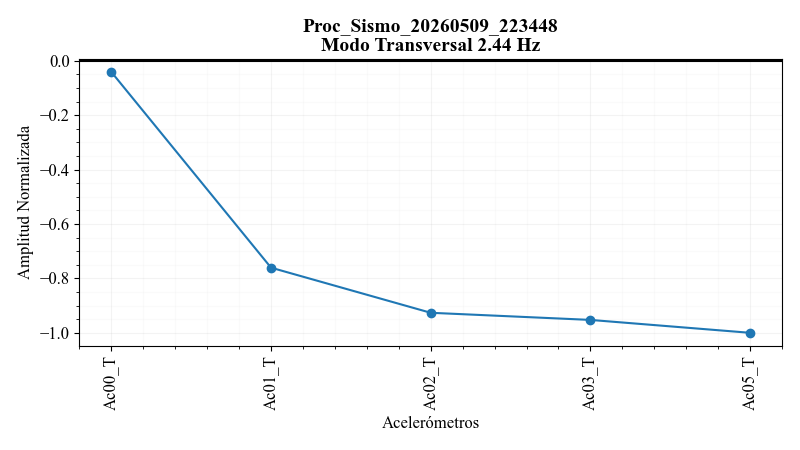

Archivo: Proc_Sismo_20260509_223448.txt
Fn = 4.7 Hz


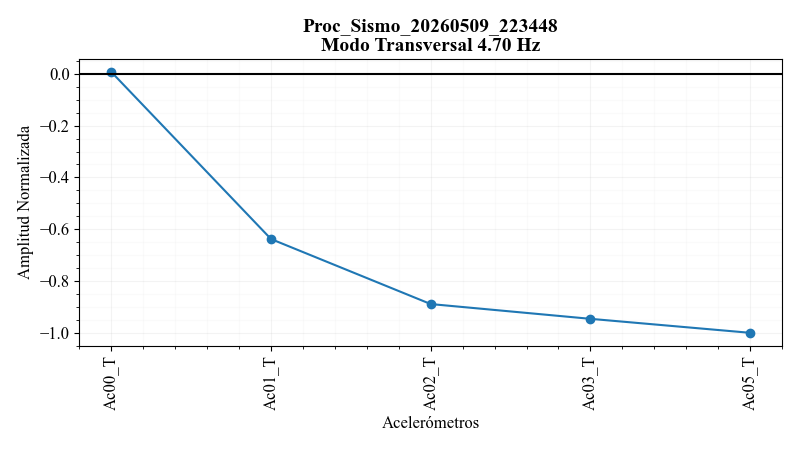

Archivo: Proc_Sismo_20260509_223448.txt
Fn = 6.16 Hz


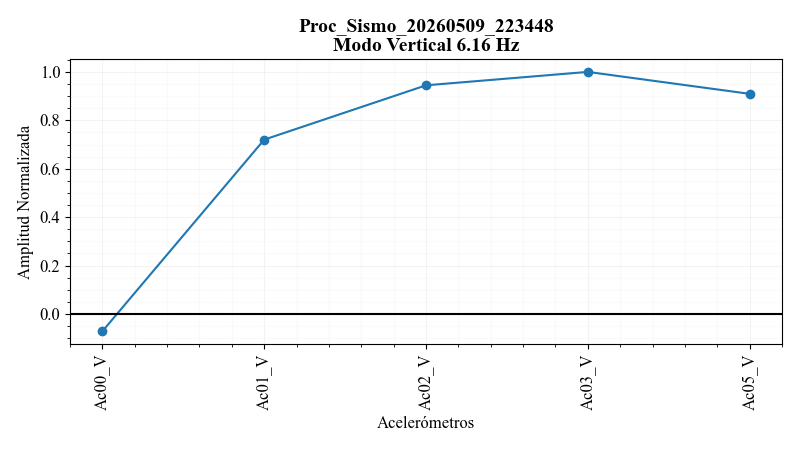

Archivo: Proc_Sismo_20260509_223448.txt
Fn = 6.23 Hz


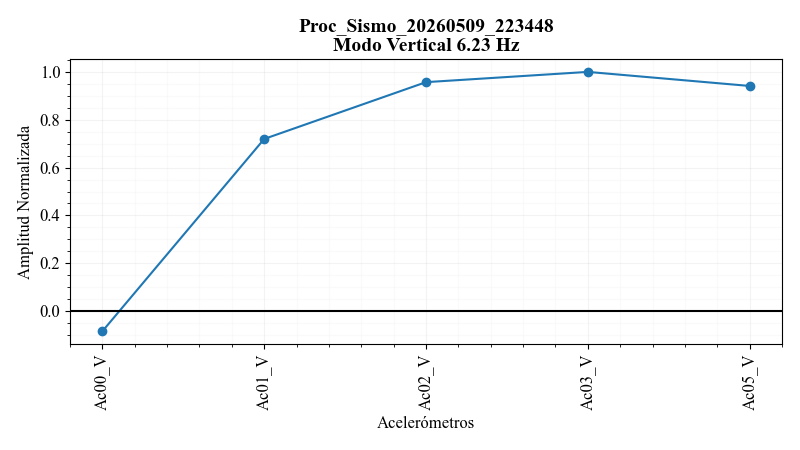

In [ ]:
arch_analizado = 0
frec_obj = 2.44 #Hz
direc_modo = 'T'

forma_modal(arch_analizado, frec_obj, direc_modo)

arch_analizado = 0
frec_obj = 4.70 #Hz
direc_modo = 'T'

forma_modal(arch_analizado, frec_obj, direc_modo)

arch_analizado = 0
frec_obj = 6.16 #Hz
direc_modo = 'V'

forma_modal(arch_analizado, frec_obj, direc_modo)

arch_analizado = 0
frec_obj = 6.23 #Hz
direc_modo = 'V'

forma_modal(arch_analizado, frec_obj, direc_modo)

In [ ]:
for i, peaks in enumerate(freq_peaks_pond):
    print(f'{i}\t{peaks:.5f} Hz')

0	0.67139 Hz
1	1.22070 Hz
2	1.46484 Hz
3	1.95312 Hz
4	2.44141 Hz
5	2.80762 Hz
6	3.05176 Hz
7	3.41797 Hz
8	3.72314 Hz
9	3.90625 Hz
10	4.33350 Hz
11	4.51660 Hz
12	4.69971 Hz
13	5.00488 Hz
14	5.24902 Hz
15	5.37109 Hz
16	5.85938 Hz
17	6.04248 Hz
18	6.28662 Hz
19	6.77490 Hz
20	6.95801 Hz
21	7.14111 Hz
22	7.87354 Hz
23	8.23975 Hz
24	8.48389 Hz
25	8.66699 Hz
26	8.91113 Hz
27	9.15527 Hz
28	9.33838 Hz
29	9.64355 Hz
30	9.88770 Hz


In [ ]:
# ============================================================
# COMPARACIÓN SAP2000 vs OMA CON TOLERANCIA ±5%
# ============================================================

modos_OMA = {'modo1':freq_peaks_pond[7]*0.975,'modo2':freq_peaks_pond[15],'modo3':freq_peaks_pond[24]}
modos_SAP2000 = {'modo1':2.53604,'modo2':4.70006, 'modo3':5.97613}
#Calibración E*0.88 + DEAD*1.2 en Mass Source
#modos_SAP2000 = {'modo1':2.56271,'modo2':4.43095, 'modo3':6.33819}

tolerancia = 5  # %

# ============================================================
# VERIFICACIÓN
# ============================================================

for modo in modos_OMA:
    f_oma = modos_OMA[modo]
    f_sap = modos_SAP2000[modo]

    # Error porcentual respecto al OMA
    error = abs(f_sap - f_oma) / f_oma * 100

    # Rango permitido ±5%
    limite_inf = f_oma * (1 - tolerancia/100)
    limite_sup = f_oma * (1 + tolerancia/100)

    # Verificación
    cumple = limite_inf <= f_sap <= limite_sup

    print('='*40)
    print(modo.upper())
    print(f'OMA      : {f_oma:.6f} Hz')
    print(f'SAP2000  : {f_sap:.6f} Hz')
    print(f'Error    : {error:.3f} %')
    print(f'Rango 5% : [{limite_inf:.6f} , {limite_sup:.6f}] Hz')

    if cumple: print('Estado   : DENTRO del margen ±5%')
    else: print('Estado   : FUERA del margen ±5%')

MODO1
OMA      : 3.332520 Hz
SAP2000  : 2.536040 Hz
Error    : 23.900 %
Rango 5% : [3.165894 , 3.499146] Hz
Estado   : FUERA del margen ±5%
MODO2
OMA      : 5.371094 Hz
SAP2000  : 4.700060 Hz
Error    : 12.493 %
Rango 5% : [5.102539 , 5.639648] Hz
Estado   : FUERA del margen ±5%
MODO3
OMA      : 8.483887 Hz
SAP2000  : 5.976130 Hz
Error    : 29.559 %
Rango 5% : [8.059692 , 8.908081] Hz
Estado   : FUERA del margen ±5%
